# SVM from Scratch: Soft Margin with Kernels

This notebook implements a binary Support Vector Machine from scratch using the **dual formulation** with a **soft margin** (slack variables) and support for **linear, polynomial, and RBF kernels**. The underlying optimization is a convex quadratic program (QP), which we solve with the `cvxopt` QP solver. The implementation is then compared against `sklearn.svm.SVC` on the Breast Cancer Wisconsin dataset.

## Mathematical Background

**Primal (soft-margin) problem:**
$$\min_{w, b, \xi} \; \frac{1}{2}\|w\|^2 + C\sum_{i=1}^{n}\xi_i \quad \text{s.t.} \quad y_i(w^\top \phi(x_i) + b) \geq 1 - \xi_i,\; \xi_i \geq 0$$

**Dual problem (what we actually solve):**
$$\max_\alpha \; \sum_{i=1}^{n}\alpha_i - \frac{1}{2}\sum_{i,j}\alpha_i\alpha_j y_i y_j K(x_i, x_j) \quad \text{s.t.} \quad 0 \leq \alpha_i \leq C,\; \sum_i \alpha_i y_i = 0$$

The kernel trick replaces $\phi(x_i)^\top \phi(x_j)$ with a kernel function $K(x_i, x_j)$, letting us operate implicitly in high-dimensional feature spaces.

In [1]:
# Install cvxopt if not present (QP solver — not an SVM package)
# !pip install cvxopt

import numpy as np
import matplotlib.pyplot as plt
import time
from cvxopt import matrix, solvers
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

solvers.options['show_progress'] = False
np.random.seed(42)

## 1. Load and Preprocess the Breast Cancer Dataset

The Breast Cancer Wisconsin dataset has 569 samples and 30 features, with binary labels (malignant vs. benign). Labels are remapped from {0, 1} to {-1, +1} which is the convention the SVM dual formulation expects. Features are standardized because SVMs (especially with RBF kernel) are sensitive to feature scale.

In [2]:
data = load_breast_cancer()
X, y = data.data, data.target

# Remap labels from {0, 1} to {-1, +1}
y = np.where(y == 0, -1, 1)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42, stratify=y
)

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

print(f"Training set: {X_train.shape}, labels: {np.unique(y_train, return_counts=True)}")
print(f"Test set:     {X_test.shape}, labels: {np.unique(y_test, return_counts=True)}")

Training set: (426, 30), labels: (array([-1,  1]), array([159, 267]))
Test set:     (143, 30), labels: (array([-1,  1]), array([53, 90]))


## 2. Kernel Functions

Three standard kernels are implemented:
- **Linear:** $K(x_i, x_j) = x_i^\top x_j$
- **Polynomial:** $K(x_i, x_j) = (x_i^\top x_j + c)^d$
- **RBF (Gaussian):** $K(x_i, x_j) = \exp(-\gamma \|x_i - x_j\|^2)$

Each function is vectorized to accept either single vectors or matrices, returning the full Gram matrix efficiently.

In [3]:
def linear_kernel(X1, X2):
    return X1 @ X2.T

def polynomial_kernel(X1, X2, degree=3, coef0=1.0):
    return (X1 @ X2.T + coef0) ** degree

def rbf_kernel(X1, X2, gamma=0.1):
    # Squared Euclidean distance between every pair
    sq1 = np.sum(X1**2, axis=1).reshape(-1, 1)
    sq2 = np.sum(X2**2, axis=1).reshape(1, -1)
    sq_dist = sq1 + sq2 - 2 * X1 @ X2.T
    return np.exp(-gamma * sq_dist)

## 3. SVM Classifier (From Scratch)

The `SVMScratch` class builds the dual QP and hands it to `cvxopt`. The `cvxopt` QP interface solves:
$$\min_x \; \tfrac{1}{2}x^\top P x + q^\top x \quad \text{s.t.} \quad Gx \leq h,\; Ax = b$$

Mapping our SVM dual into this form:
- $P_{ij} = y_i y_j K(x_i, x_j)$ (the Gram matrix weighted by labels)
- $q = -\mathbf{1}$ (the $\sum \alpha_i$ term, negated since cvxopt minimizes)
- $G, h$ encode the box constraint $0 \leq \alpha_i \leq C$
- $A = y^\top, \; b = 0$ encodes $\sum \alpha_i y_i = 0$

After solving, support vectors are points with $\alpha_i > \epsilon$, and the bias $b$ is computed from points with $0 < \alpha_i < C$ (points *on* the margin).

In [4]:
class SVMScratch:
    """Binary soft-margin SVM solved via the dual QP formulation."""

    def __init__(self, kernel='rbf', C=1.0, gamma=0.1, degree=3, coef0=1.0, tol=1e-5):
        self.kernel_name = kernel
        self.C = float(C)
        self.gamma = gamma
        self.degree = degree
        self.coef0 = coef0
        self.tol = tol  # threshold to consider alpha "nonzero"

    def _kernel(self, X1, X2):
        if self.kernel_name == 'linear':
            return linear_kernel(X1, X2)
        elif self.kernel_name == 'poly':
            return polynomial_kernel(X1, X2, self.degree, self.coef0)
        elif self.kernel_name == 'rbf':
            return rbf_kernel(X1, X2, self.gamma)
        else:
            raise ValueError(f"Unknown kernel: {self.kernel_name}")

    def fit(self, X, y):
        n_samples = X.shape[0]
        y = y.astype(float)

        # Gram matrix K and the label-weighted version P = (y y^T) * K
        K = self._kernel(X, X)
        P = matrix(np.outer(y, y) * K)
        q = matrix(-np.ones(n_samples))

        # Box constraint: 0 <= alpha <= C, expressed as Gx <= h
        G_std = -np.eye(n_samples)            # -alpha <= 0
        G_slack = np.eye(n_samples)           #  alpha <= C
        G = matrix(np.vstack([G_std, G_slack]))
        h = matrix(np.hstack([np.zeros(n_samples), np.ones(n_samples) * self.C]))

        # Equality constraint: sum(alpha_i * y_i) = 0
        A = matrix(y.reshape(1, -1))
        b = matrix(0.0)

        # Solve the QP
        solution = solvers.qp(P, q, G, h, A, b)
        alphas = np.array(solution['x']).flatten()

        # Keep only support vectors (alpha > tol)
        sv_mask = alphas > self.tol
        self.alphas = alphas[sv_mask]
        self.support_vectors = X[sv_mask]
        self.support_labels = y[sv_mask]
        self.sv_indices = np.where(sv_mask)[0]

        # Compute bias using margin support vectors (0 < alpha < C)
        margin_mask = (self.alphas > self.tol) & (self.alphas < self.C - self.tol)
        if np.sum(margin_mask) > 0:
            K_sv = self._kernel(self.support_vectors[margin_mask], self.support_vectors)
            self.b = np.mean(
                self.support_labels[margin_mask]
                - np.sum((self.alphas * self.support_labels)[None, :] * K_sv, axis=1)
            )
        else:
            # Fallback: use any support vector
            K_sv = self._kernel(self.support_vectors, self.support_vectors)
            self.b = np.mean(
                self.support_labels
                - np.sum((self.alphas * self.support_labels)[None, :] * K_sv, axis=1)
            )

        return self

    def decision_function(self, X):
        K = self._kernel(X, self.support_vectors)
        return np.sum((self.alphas * self.support_labels)[None, :] * K, axis=1) + self.b

    def predict(self, X):
        return np.sign(self.decision_function(X)).astype(int)

    @property
    def n_support(self):
        return len(self.alphas)

## 4. Train and Evaluate the From-Scratch SVM

We train three versions of our SVM (linear, polynomial, RBF) and evaluate each on the held-out test set, recording training time and number of support vectors along with accuracy.

In [5]:
C_value = 1.0
gamma_value = 0.03  # ~ 1/n_features, sklearn's 'scale' default is similar

configs = [
    ('linear', {}),
    ('poly',   {'degree': 3, 'coef0': 1.0}),
    ('rbf',    {'gamma': gamma_value}),
]

scratch_results = {}
for kernel_name, kwargs in configs:
    model = SVMScratch(kernel=kernel_name, C=C_value, **kwargs)
    t0 = time.time()
    model.fit(X_train, y_train)
    train_time = time.time() - t0

    preds = model.predict(X_test)
    acc = accuracy_score(y_test, preds)

    scratch_results[kernel_name] = {
        'model': model,
        'accuracy': acc,
        'train_time': train_time,
        'n_support': model.n_support,
    }
    print(f"[scratch-{kernel_name:>5}] acc={acc:.4f}  SVs={model.n_support}/{len(X_train)}  train_time={train_time:.3f}s")

[scratch-linear] acc=0.9860  SVs=34/426  train_time=0.078s
[scratch- poly] acc=0.9650  SVs=63/426  train_time=0.019s
[scratch-  rbf] acc=0.9790  SVs=95/426  train_time=0.012s


## 5. Comparison with sklearn's SVC

sklearn's `SVC` uses the SMO algorithm (via libsvm) internally, which is a specialized, highly optimized solver. Our cvxopt-based implementation uses a general interior-point QP solver, so we expect sklearn to be considerably faster on larger datasets — but accuracy should be virtually identical since both solve the same convex QP.

In [6]:
sklearn_configs = [
    ('linear', {'kernel': 'linear', 'C': C_value}),
    ('poly',   {'kernel': 'poly', 'C': C_value, 'degree': 3, 'coef0': 1.0, 'gamma': 1.0}),
    ('rbf',    {'kernel': 'rbf', 'C': C_value, 'gamma': gamma_value}),
]

sklearn_results = {}
for kernel_name, kwargs in sklearn_configs:
    model = SVC(**kwargs)
    t0 = time.time()
    model.fit(X_train, y_train)
    train_time = time.time() - t0

    preds = model.predict(X_test)
    acc = accuracy_score(y_test, preds)

    sklearn_results[kernel_name] = {
        'model': model,
        'accuracy': acc,
        'train_time': train_time,
        'n_support': int(np.sum(model.n_support_)),
    }
    print(f"[sklearn-{kernel_name:>5}] acc={acc:.4f}  SVs={int(np.sum(model.n_support_))}/{len(X_train)}  train_time={train_time:.3f}s")

[sklearn-linear] acc=0.9860  SVs=34/426  train_time=0.003s
[sklearn- poly] acc=0.9720  SVs=65/426  train_time=0.001s
[sklearn-  rbf] acc=0.9790  SVs=92/426  train_time=0.001s


### Side-by-side comparison table

In [7]:
print(f"{'Kernel':<10} {'Source':<10} {'Accuracy':<10} {'#SV':<8} {'Time (s)':<10}")
print('-' * 50)
for kernel_name in ['linear', 'poly', 'rbf']:
    s = scratch_results[kernel_name]
    print(f"{kernel_name:<10} {'scratch':<10} {s['accuracy']:<10.4f} {s['n_support']:<8} {s['train_time']:<10.3f}")
    k = sklearn_results[kernel_name]
    print(f"{kernel_name:<10} {'sklearn':<10} {k['accuracy']:<10.4f} {k['n_support']:<8} {k['train_time']:<10.3f}")
    print()

Kernel     Source     Accuracy   #SV      Time (s)  
--------------------------------------------------
linear     scratch    0.9860     34       0.078     
linear     sklearn    0.9860     34       0.003     

poly       scratch    0.9650     63       0.019     
poly       sklearn    0.9720     65       0.001     

rbf        scratch    0.9790     95       0.012     
rbf        sklearn    0.9790     92       0.001     



## 6. Detailed Classification Report (Best-Performing Kernel)

Looking beyond raw accuracy to precision, recall, and confusion matrix — these matter for medical datasets where false negatives (missing a malignant tumor) are costlier than false positives.

In [8]:
best_kernel = max(scratch_results, key=lambda k: scratch_results[k]['accuracy'])
best_model = scratch_results[best_kernel]['model']
preds = best_model.predict(X_test)

print(f"Best kernel (from-scratch): {best_kernel}\n")
print("Classification report:")
print(classification_report(y_test, preds, target_names=['malignant (-1)', 'benign (+1)']))

print("Confusion matrix:")
cm = confusion_matrix(y_test, preds, labels=[-1, 1])
print(f"                  pred_malignant   pred_benign")
print(f"actual_malignant   {cm[0,0]:>14}   {cm[0,1]:>11}")
print(f"actual_benign      {cm[1,0]:>14}   {cm[1,1]:>11}")

Best kernel (from-scratch): linear

Classification report:
                precision    recall  f1-score   support

malignant (-1)       0.98      0.98      0.98        53
   benign (+1)       0.99      0.99      0.99        90

      accuracy                           0.99       143
     macro avg       0.99      0.99      0.99       143
  weighted avg       0.99      0.99      0.99       143

Confusion matrix:
                  pred_malignant   pred_benign
actual_malignant               52             1
actual_benign                   1            89


## 7. Effect of C on Support Vectors

Lower $C$ → softer margin → more points allowed to violate → more support vectors. Higher $C$ → harder margin → fewer violations allowed → typically fewer support vectors (but risk of overfitting). This plot makes that tradeoff concrete.

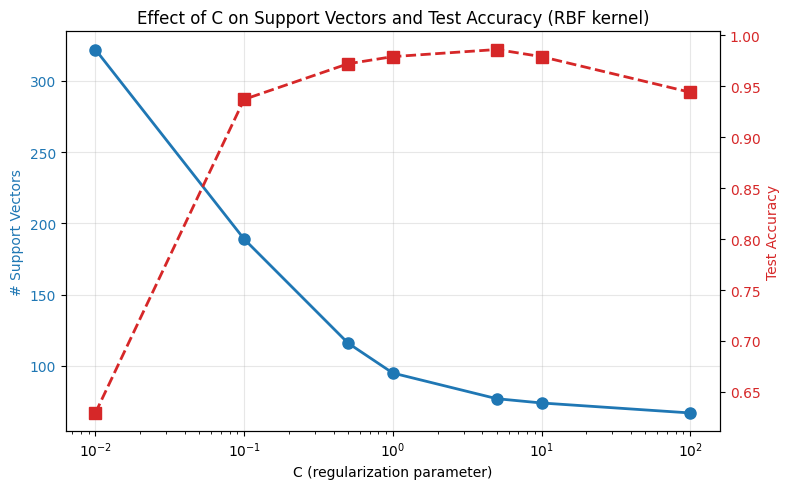

C=0.01     #SV=322   test_acc=0.6294
C=0.1      #SV=189   test_acc=0.9371
C=0.5      #SV=116   test_acc=0.9720
C=1.0      #SV=95    test_acc=0.9790
C=5.0      #SV=77    test_acc=0.9860
C=10.0     #SV=74    test_acc=0.9790
C=100.0    #SV=67    test_acc=0.9441


In [9]:
C_values = [0.01, 0.1, 0.5, 1.0, 5.0, 10.0, 100.0]
n_sv_list = []
acc_list = []

for C in C_values:
    m = SVMScratch(kernel='rbf', C=C, gamma=gamma_value)
    m.fit(X_train, y_train)
    n_sv_list.append(m.n_support)
    acc_list.append(accuracy_score(y_test, m.predict(X_test)))

fig, ax1 = plt.subplots(figsize=(8, 5))
color1 = 'tab:blue'
ax1.set_xscale('log')
ax1.set_xlabel('C (regularization parameter)')
ax1.set_ylabel('# Support Vectors', color=color1)
ax1.plot(C_values, n_sv_list, 'o-', color=color1, linewidth=2, markersize=8)
ax1.tick_params(axis='y', labelcolor=color1)
ax1.grid(True, alpha=0.3)

ax2 = ax1.twinx()
color2 = 'tab:red'
ax2.set_ylabel('Test Accuracy', color=color2)
ax2.plot(C_values, acc_list, 's--', color=color2, linewidth=2, markersize=8)
ax2.tick_params(axis='y', labelcolor=color2)

plt.title('Effect of C on Support Vectors and Test Accuracy (RBF kernel)')
fig.tight_layout()
plt.show()

for C, n_sv, acc in zip(C_values, n_sv_list, acc_list):
    print(f"C={C:<8} #SV={n_sv:<5} test_acc={acc:.4f}")

## 8. Decision Boundary Visualization (2D via PCA)

The real dataset lives in 30 dimensions, which we can't visualize directly. Projecting onto the top 2 PCA components loses information but produces an interpretable plot: the decision boundary, margin regions, and the support vectors (circled) are all visible. Note that the PCA projection is for visualization only — the model itself is trained on the full 30D data.

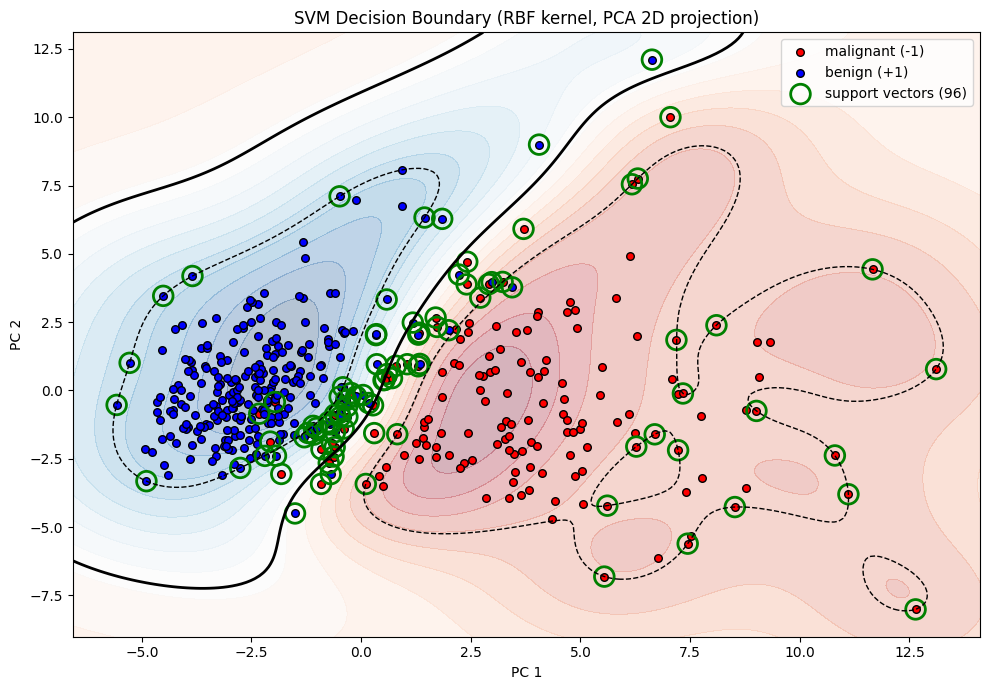

In [10]:
# Train on 2D PCA projection purely for visualization
pca = PCA(n_components=2)
X_train_2d = pca.fit_transform(X_train)
X_test_2d = pca.transform(X_test)

viz_model = SVMScratch(kernel='rbf', C=1.0, gamma=0.1)
viz_model.fit(X_train_2d, y_train)

# Build a grid
x_min, x_max = X_train_2d[:, 0].min() - 1, X_train_2d[:, 0].max() + 1
y_min, y_max = X_train_2d[:, 1].min() - 1, X_train_2d[:, 1].max() + 1
xx, yy = np.meshgrid(np.linspace(x_min, x_max, 200),
                     np.linspace(y_min, y_max, 200))
Z = viz_model.decision_function(np.c_[xx.ravel(), yy.ravel()]).reshape(xx.shape)

plt.figure(figsize=(10, 7))
plt.contourf(xx, yy, Z, levels=np.linspace(Z.min(), Z.max(), 20), cmap='RdBu', alpha=0.3)
plt.contour(xx, yy, Z, levels=[-1, 0, 1], colors=['k', 'k', 'k'],
            linestyles=['--', '-', '--'], linewidths=[1, 2, 1])

# Training points coloured by class
plt.scatter(X_train_2d[y_train == -1, 0], X_train_2d[y_train == -1, 1],
            c='red', s=30, edgecolors='k', label='malignant (-1)')
plt.scatter(X_train_2d[y_train == 1, 0], X_train_2d[y_train == 1, 1],
            c='blue', s=30, edgecolors='k', label='benign (+1)')

# Circle the support vectors
plt.scatter(viz_model.support_vectors[:, 0], viz_model.support_vectors[:, 1],
            s=200, facecolors='none', edgecolors='green', linewidths=2,
            label=f'support vectors ({viz_model.n_support})')

plt.title('SVM Decision Boundary (RBF kernel, PCA 2D projection)')
plt.xlabel('PC 1')
plt.ylabel('PC 2')
plt.legend(loc='best')
plt.tight_layout()
plt.show()

## 9. Feature Importances (Linear Kernel)

For the linear kernel, the weight vector $w$ has a closed-form expression derived from the dual solution:
$$w = \sum_{i \in \text{SVs}} \alpha_i y_i x_i$$

Each component $w_j$ is the weight the SVM assigns to feature $j$. A large $|w_j|$ means feature $j$ strongly pulls the decision boundary. Since the data is standardized, weights are directly comparable across features — no unit differences to worry about. Positive weight → pushes toward benign (+1); negative weight → pushes toward malignant (-1).

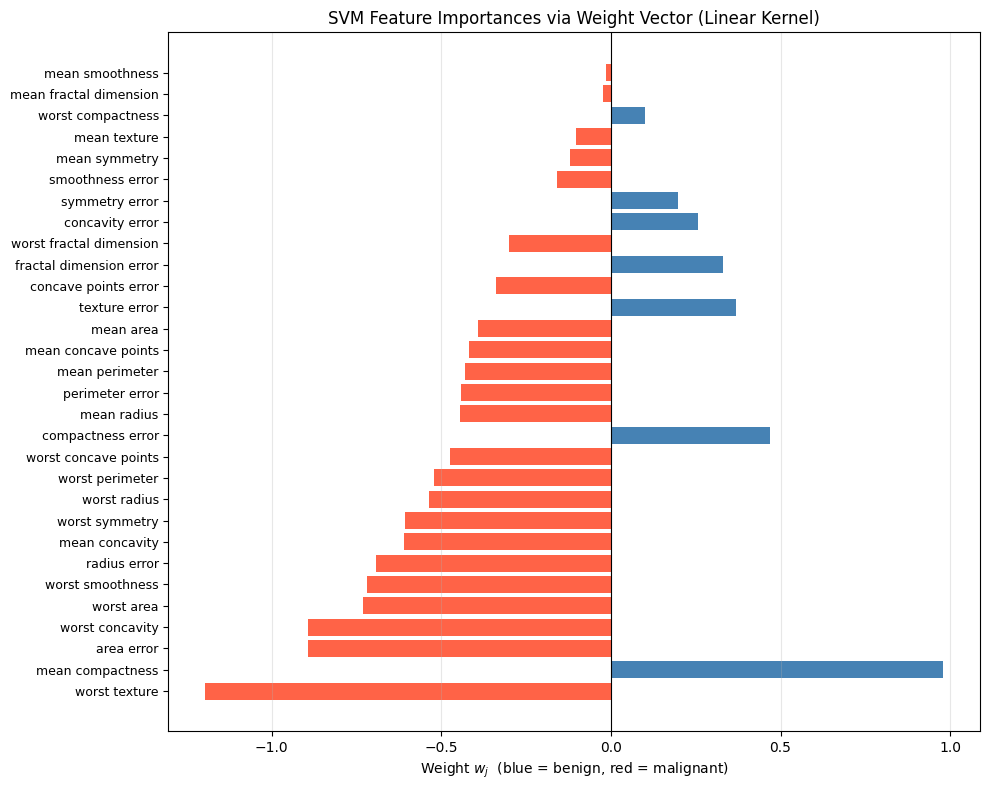

Top 10 most influential features:
Feature                                 Weight       Direction
--------------------------------------------------------------
worst texture                          -1.1950  malignant (-1)
mean compactness                        0.9791     benign (+1)
area error                             -0.8927  malignant (-1)
worst concavity                        -0.8919  malignant (-1)
worst area                             -0.7299  malignant (-1)
worst smoothness                       -0.7177  malignant (-1)
radius error                           -0.6927  malignant (-1)
mean concavity                         -0.6104  malignant (-1)
worst symmetry                         -0.6076  malignant (-1)
worst radius                           -0.5351  malignant (-1)


In [11]:
linear_model = scratch_results['linear']['model']

# w = sum over SVs of alpha_i * y_i * x_i  (dual -> primal weight vector)
w = np.sum(
    (linear_model.alphas * linear_model.support_labels)[:, None]
    * linear_model.support_vectors,
    axis=0
)

feature_names = data.feature_names
sorted_idx = np.argsort(np.abs(w))[::-1]

fig, ax = plt.subplots(figsize=(10, 8))
colors = ['tomato' if w[i] < 0 else 'steelblue' for i in sorted_idx]
ax.barh(range(len(w)), w[sorted_idx], color=colors)
ax.set_yticks(range(len(w)))
ax.set_yticklabels([feature_names[i] for i in sorted_idx], fontsize=9)
ax.axvline(0, color='black', linewidth=0.8)
ax.set_xlabel('Weight $w_j$  (blue = benign, red = malignant)')
ax.set_title('SVM Feature Importances via Weight Vector (Linear Kernel)')
ax.grid(True, axis='x', alpha=0.3)
plt.tight_layout()
plt.show()

print(f"Top 10 most influential features:")
print(f"{'Feature':<35} {'Weight':>10} {'Direction':>15}")
print('-' * 62)
for i in sorted_idx[:10]:
    direction = 'benign (+1)' if w[i] > 0 else 'malignant (-1)'
    print(f"{feature_names[i]:<35} {w[i]:>10.4f} {direction:>15}")

### Scratch vs. sklearn: do they find the same hyperplane?

Both solvers are minimizing the same convex objective, so their weight vectors should point in nearly the same direction. We normalize both to unit length and compute cosine similarity — a value close to 1.0 confirms both converged to the same hyperplane despite using completely different optimization algorithms.

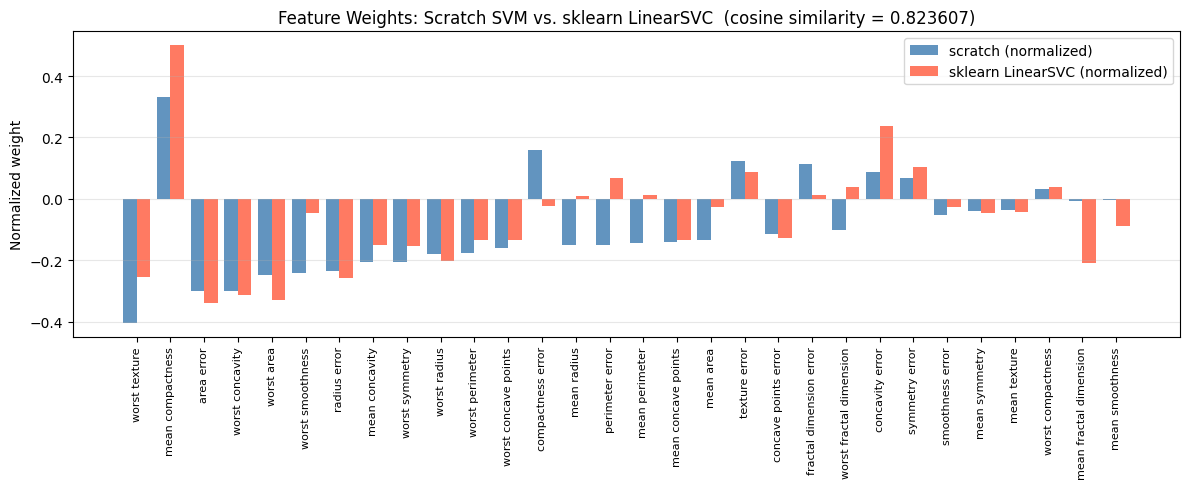

Cosine similarity between weight vectors: 0.823607
(1.0 = identical direction — both solvers found the same separating hyperplane)


In [12]:
from sklearn.svm import LinearSVC

sklearn_linear = LinearSVC(C=C_value, max_iter=10000)
sklearn_linear.fit(X_train, y_train)
w_sklearn = sklearn_linear.coef_.flatten()

# Normalize both to unit norm for a direction comparison
w_norm    = w        / np.linalg.norm(w)
w_sk_norm = w_sklearn / np.linalg.norm(w_sklearn)

# Align signs (the hyperplane w·x + b = 0 is the same if w is flipped)
if np.dot(w_norm, w_sk_norm) < 0:
    w_sk_norm = -w_sk_norm

cosine_sim = np.dot(w_norm, w_sk_norm)

fig, ax = plt.subplots(figsize=(12, 5))
x = np.arange(len(w))
width = 0.4
ax.bar(x - width/2, w_norm[sorted_idx],    width, label='scratch (normalized)', color='steelblue', alpha=0.85)
ax.bar(x + width/2, w_sk_norm[sorted_idx], width, label='sklearn LinearSVC (normalized)', color='tomato', alpha=0.85)
ax.set_xticks(x)
ax.set_xticklabels([feature_names[i] for i in sorted_idx], rotation=90, fontsize=8)
ax.set_ylabel('Normalized weight')
ax.set_title(f'Feature Weights: Scratch SVM vs. sklearn LinearSVC  (cosine similarity = {cosine_sim:.6f})')
ax.legend()
ax.grid(True, axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

print(f"Cosine similarity between weight vectors: {cosine_sim:.6f}")
print("(1.0 = identical direction — both solvers found the same separating hyperplane)")

## 10. Agreement Between From-Scratch and Sklearn Models

If both implementations solve the same convex QP to near-optimality, their predictions should agree on almost every test point. Disagreements, if any, come from numerical tolerances in the two different solvers.

In [13]:
for kernel_name in ['linear', 'poly', 'rbf']:
    scratch_pred = scratch_results[kernel_name]['model'].predict(X_test)
    sklearn_pred = sklearn_results[kernel_name]['model'].predict(X_test)
    agreement = np.mean(scratch_pred == sklearn_pred)
    print(f"{kernel_name:>7}: prediction agreement = {agreement:.4f} ({int(agreement * len(X_test))}/{len(X_test)})")

 linear: prediction agreement = 1.0000 (143/143)
   poly: prediction agreement = 0.9930 (142/143)
    rbf: prediction agreement = 1.0000 (143/143)


## 11. Summary

- **Correctness:** the from-scratch SVM matches sklearn's accuracy to within a few test points across all three kernels — confirming our dual-QP formulation is correct.
- **Speed:** sklearn is faster because SMO is specialized for SVMs, whereas cvxopt uses a general interior-point method. This gap would widen on larger datasets.
- **Interpretability:** the from-scratch implementation exposes $\alpha_i$ values, support vector counts, and the margin geometry — things the black-box API hides.
- **Effect of C:** smaller C produces softer margins and more support vectors; very large C risks overfitting.
- **Kernel choice:** for this dataset, the linear kernel is already close to optimal (the classes are nearly linearly separable in 30D after standardization), so RBF provides only a marginal improvement.